In [1]:
%load_ext autoreload
%autoreload 2 


In [2]:
%matplotlib inline

In [3]:

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch

import os
import sys

from pathlib import Path

import json

path_solo = str(Path(os.path.abspath('.')).resolve().parent)
sys.path.append(path_solo)

from omegaconf import OmegaConf

from solo.methods import METHODS
from solo.methods.base import BaseMethod

import timm

from segmentor.segmentation import segment_protein_aggregates_tile, DinoVisionTransformerClassifier, get_attn_extractor
from torchvision.transforms import Normalize

/data/mcbs/dereure/.conda/envs/deepcellmap_6/lib/python3.10/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/data/mcbs/dereure/.conda/envs/deepcellmap_6/lib/python3.10/site-packages/timm/optim/optim_factory.py:7: FutureWarning: Importing from timm.optim.optim_factory is deprecated, please import via timm.optim
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.optim", FutureWarning)
2026-04-28 18:30:03.749537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 18:30:03.828276: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow

In [4]:
tile = Image.open("../synuclein_1.png")
tile = np.array(tile) / 255
if tile.shape[-1] == 4:
    tile = tile[..., :3]

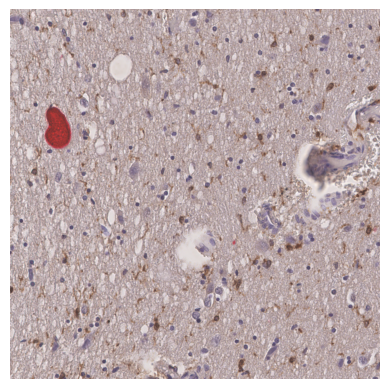

In [5]:
plt.imshow(tile)
plt.axis("off")
plt.show()

In [6]:
####### Segmentation of alpha-synuclein aggregates

In [ ]:
path_weights_segmentation = Path("path/to/weights/segmentation")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

timm.layers.set_fused_attn(False)
dino = timm.create_model(
'vit_base_patch16_dinov3.lvd1689m',
pretrained=True,
)


model_segmentation = DinoVisionTransformerClassifier(dino)

model_segmentation.load_state_dict(torch.load(path_weights_segmentation / "weights_dinov3_17"))

model_segmentation = model_segmentation.to(device)

model_segmentation.eval()

DinoVisionTransformerClassifier(
  (transformer): Eva(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (rope): RotaryEmbeddingDinoV3()
    (norm_pre): Identity()
    (blocks): ModuleList(
      (0-11): 12 x EvaBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): EvaAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=False)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
     

In [8]:
attn_extractor = get_attn_extractor(model_segmentation)
attn_extractor.eval()

Eva(
  (patch_embed): Module(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (norm_pre): Identity()
  (blocks): Module(
    (0): Module(
      (norm1): Module()
      (attn): Module(
        (qkv): Linear(in_features=768, out_features=2304, bias=False)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): Module()
      (mlp): Module(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop2): Dropout(p=0.0, inplace=False)
      )
      (d

In [9]:
segmentation_protein_aggregates, segmentation_protein_aggregates_all, crops_aggregates, dict_aggregates = segment_protein_aggregates_tile(tile, model_segmentation, attn_extractor, device)

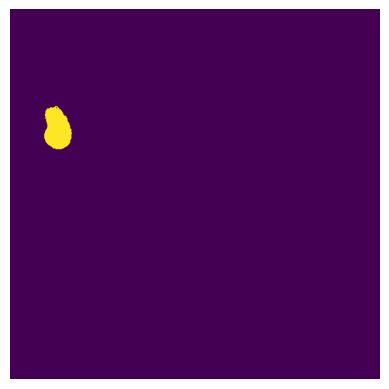

In [10]:
plt.imshow(segmentation_protein_aggregates)
plt.axis("off")
plt.show()

In [11]:
####### Classification of alpha-synuclein aggregates

In [12]:
crop_aggregate = crops_aggregates['rgb'][0]

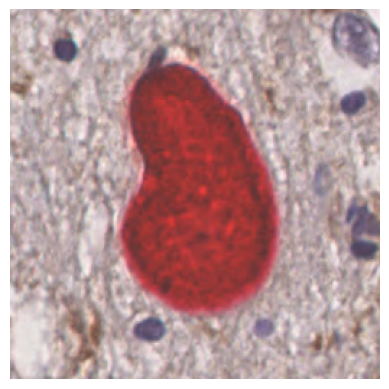

In [13]:
plt.imshow(crop_aggregate)
plt.axis("off")
plt.show()

In [ ]:
ckpt_dir = Path("path/to/weights/classification") / "hc3297ve"
args_path = ckpt_dir / "args.json"
ckpt_path = [ckpt_dir / ckpt for ckpt in os.listdir(ckpt_dir) if ckpt.endswith(".ckpt")][0]

# load arguments
with open(args_path) as f:
    method_args = json.load(f)
cfg = OmegaConf.create(method_args)

backbone_model = BaseMethod._BACKBONES[cfg.backbone.name]

# initialize backbone
backbone = backbone_model(method=cfg.pretrain_method, **cfg.backbone.kwargs)
if cfg.backbone.name.startswith("resnet"):
    # remove fc layer
    backbone.fc = torch.nn.Identity()
    cifar = cfg.data.dataset in ["cifar10", "cifar100"]
    if cifar:
        backbone.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=2, bias=False)
        backbone.maxpool = torch.nn.Identity()


aggregates_class_names = ["axon",
                        "dendrite",
                        "lewy",
                        "middle",
                        "multiple",
                        "scattered"]

model_classification = (
    METHODS["linear"]
    .load_from_checkpoint(ckpt_path, backbone=backbone, strict=False, cfg=cfg, class_names=aggregates_class_names)
)

model_classification = model_classification.to(device)
model_classification.eval()


/data/mcbs/dereure/.conda/envs/deepcellmap_6/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/mcbs/dereure/.conda/envs/deepcellmap_6/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/data/mcbs/dereure/.conda/envs/deepcellmap_6/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['loss_func.weight']


LinearModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
     

In [15]:
crop_rgb = np.transpose(crop_aggregate, (-1, 0, 1)) 

normalize = Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

crop_rgb = torch.from_numpy(crop_rgb)[None, ...]
crop_rgb = normalize(crop_rgb.float().to(device))

with torch.no_grad():
    logits = model_classification(crop_rgb.to(device))["logits"]
probas = torch.softmax(logits, dim=1).flatten().cpu().detach().numpy()

In [16]:
aggregates_class_names[probas.argmax()]

'axon'